In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd


# ==================================================
# 1. THÔNG SỐ
# ==================================================

fs = 44100
f = 440
duration = 8
I = 5

t = np.arange(0, duration, 1/fs)


# ==================================================
# 2. TẠO ĐƯỜNG BAO A(t)
# ==================================================

A = np.ones(len(t))

# Attack
T_attack = 0.01
N_attack = int(T_attack * fs)

A[:N_attack] = np.linspace(0, 1, N_attack)


# Decay
T_decay = 0.4
N_decay = int(T_decay * fs)

start_decay = N_attack
end_decay = start_decay + N_decay

u = np.linspace(0, 1, N_decay)

A[start_decay:end_decay] = (
    0.3
    + 0.7 *
    (np.exp(-5 * u) - np.exp(-5))
    / (1 - np.exp(-5))
)


# Sustain
A[end_decay:] = 0.3


# Release
T_release = 0.8
N_release = int(T_release * fs)

start_release = len(t) - N_release

u = np.linspace(0, 1, N_release)

A[start_release:] = (
    0.3 *
    (np.exp(-5 * u) - np.exp(-5))
    / (1 - np.exp(-5))
)

1. fc : fm = 1 : 1
2. fc : fm = 1 : 2
3. fc : fm = 1 : 1.414


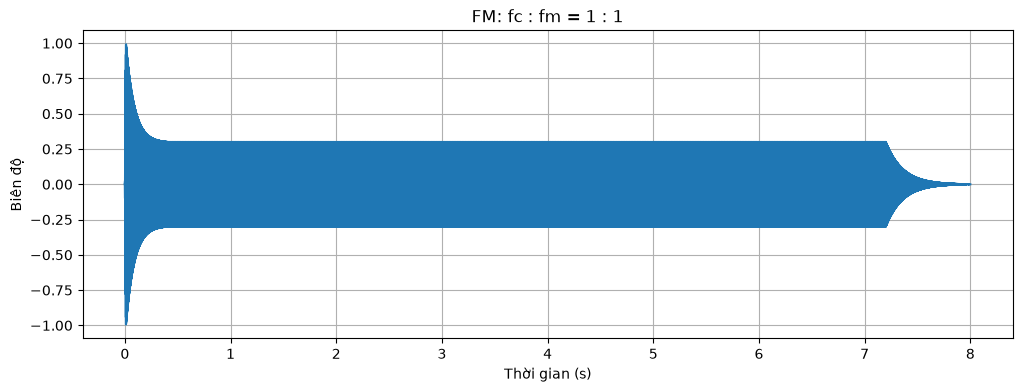

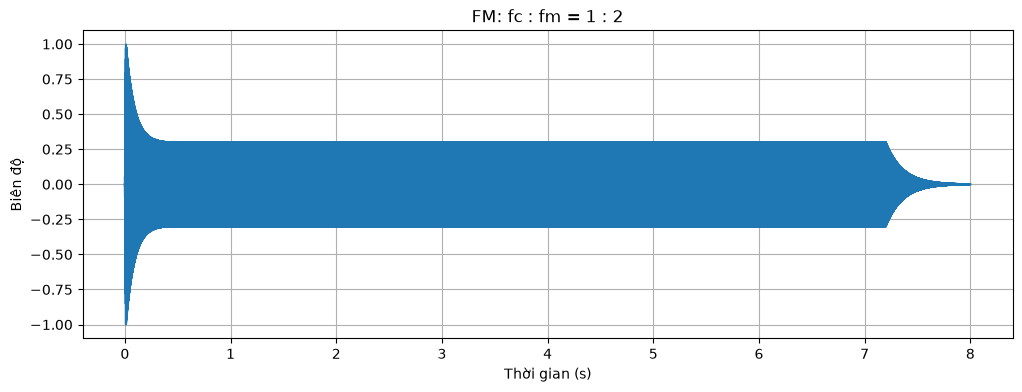

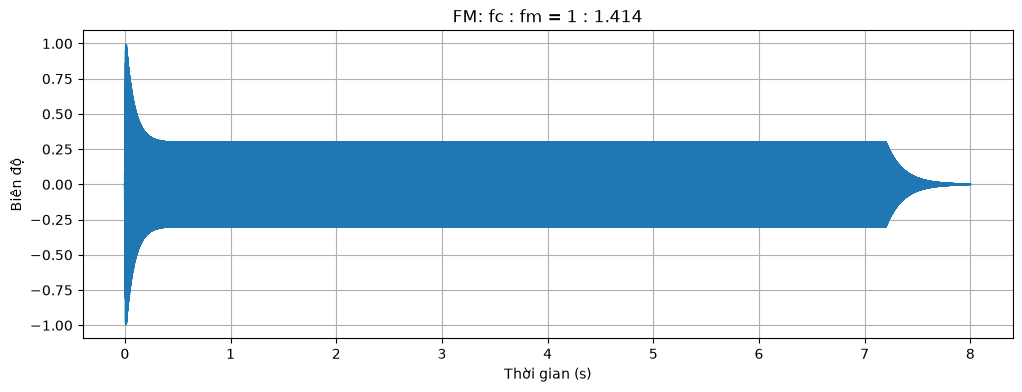

In [5]:
# ==================================================
# 3. HÀM FM SYNTHESIS
# ==================================================

def fm_sound(fc, fm):

    x = A * np.sin(
        2 * np.pi * fc * t
        + I * np.sin(2 * np.pi * fm * t)
    )

    return x


# ==================================================
# 4. TRƯỜNG HỢP 1: fc : fm = 1 : 1
# ==================================================

fc1 = f
fm1 = f

sound_1 = fm_sound(fc1, fm1)


# ==================================================
# 5. TRƯỜNG HỢP 2: fc : fm = 1 : 2
# ==================================================

fc2 = f
fm2 = 2 * f

sound_2 = fm_sound(fc2, fm2)


# ==================================================
# 6. TRƯỜNG HỢP 3: fc : fm = 1 : 1.414
# ==================================================

fc3 = f
fm3 = 1.414 * f

sound_3 = fm_sound(fc3, fm3)


# ==================================================
# 7. NGHE THỬ
# ==================================================

print("1. fc : fm = 1 : 1")
sd.play(sound_1, fs)
sd.wait()

print("2. fc : fm = 1 : 2")
sd.play(sound_2, fs)
sd.wait()

print("3. fc : fm = 1 : 1.414")
sd.play(sound_3, fs)
sd.wait()


# ==================================================
# 8. VẼ TÍN HIỆU
# ==================================================

plt.figure(figsize=(12, 4))
plt.plot(t, sound_1)

plt.xlabel("Thời gian (s)")
plt.ylabel("Biên độ")
plt.title("FM: fc : fm = 1 : 1")
plt.grid()
plt.show()


plt.figure(figsize=(12, 4))
plt.plot(t, sound_2)

plt.xlabel("Thời gian (s)")
plt.ylabel("Biên độ")
plt.title("FM: fc : fm = 1 : 2")
plt.grid()
plt.show()


plt.figure(figsize=(12, 4))
plt.plot(t, sound_3)

plt.xlabel("Thời gian (s)")
plt.ylabel("Biên độ")
plt.title("FM: fc : fm = 1 : 1.414")
plt.grid()
plt.show()